**AI-Based Incident Management System**

In [ ]:
%%capture
!pip -q install groq==0.37.1
!pip -q install langchain-groq==1.1.2
!pip -q install langchain==1.2.12
!pip -q install langchain-core==1.2.19
!pip -q install langchain_community==0.4.1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from datetime import datetime

In [ ]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

In [ ]:
from langchain_groq import ChatGroq     # <--- This is a langchain abstraction for the Groq API endpoint

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

In [ ]:
response = llm.invoke("What is 2 plus 3?")
print(response.content)

5


In [ ]:
incident_category_prompt = """
You are an incident classification assistant.

Your task is to analyze the given incident description and classify it into ONE of the following categories:

- Baggage related
- Boarding pass related
- Check-in related
- ID Proof related
- Other

Guidelines:
- Identify the primary issue described in the incident
- Focus on the main problem, not secondary details
- Choose the closest matching category
- Do NOT create new categories

Return the classification label in output and No additional text.

Incident:
{incident_text}
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

incident_category_prompt_template = ChatPromptTemplate.from_template(template=incident_category_prompt)
incident_category_prompt_template

ChatPromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, template='\nYou are an incident classification assistant.\n\nYour task is to analyze the given incident description and classify it into ONE of the following categories:\n\n- Baggage related\n- Boarding pass related\n- Check-in related\n- ID Proof related\n- Other\n\nGuidelines:\n- Identify the primary issue described in the incident\n- Focus on the main problem, not secondary details\n- Choose the closest matching category\n- Do NOT create new categories\n\nReturn the classification label in output and No additional text.\n\nIncident:\n{incident_text}\n'), additional_kwargs={})])

In [ ]:
sample_incident = "Baggage not found at arrival belt"

print(incident_category_prompt_template.invoke({"incident_text": sample_incident}).messages[0].content)


You are an incident classification assistant.

Your task is to analyze the given incident description and classify it into ONE of the following categories:

- Baggage related
- Boarding pass related
- Check-in related
- ID Proof related
- Other

Guidelines:
- Identify the primary issue described in the incident
- Focus on the main problem, not secondary details
- Choose the closest matching category
- Do NOT create new categories

Return the classification label in output and No additional text.

Incident:
Baggage not found at arrival belt



In [ ]:
from langchain_core.output_parsers import StrOutputParser

# Create LLM Chain

incident_category_clf_chain = incident_category_prompt_template | llm | StrOutputParser()

In [ ]:
incident_category_clf_chain.invoke({"incident_text": sample_incident})

'Baggage related'

In [ ]:
issue_origin_prompt = """
You are an intelligent incident classification assistant.

Your task is to analyze the given incident description and determine the **issue origin**.

Classify the issue into ONE of the following:
1. "Terms & Conditions"
   - If the issue is due to lack of awareness, misunderstanding of policies, or standard rules

2. "Operational Challenge"
   - If the issue is caused by system failures, process breakdowns, logistics issues, or unexpected real-world problems

Guidelines:
- Focus on the root cause, not just the symptoms
- Be precise and avoid ambiguity
- Choose only one category

Return the classification label in output and No additional text.

Incident:
{incident_text}
"""

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

issue_origin_prompt_template = ChatPromptTemplate.from_template(template=issue_origin_prompt)
issue_origin_prompt_template

ChatPromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, template='\nYou are an intelligent incident classification assistant.\n\nYour task is to analyze the given incident description and determine the **issue origin**.\n\nClassify the issue into ONE of the following:\n1. "Terms & Conditions"\n   - If the issue is due to lack of awareness, misunderstanding of policies, or standard rules\n\n2. "Operational Challenge"\n   - If the issue is caused by system failures, process breakdowns, logistics issues, or unexpected real-world problems\n\nGuidelines:\n- Focus on the root cause, not just the symptoms\n- Be precise and avoid ambiguity\n- Choose only one category\n\nReturn the classification label in output and No additional text.\n\nIncident:\n{incident_text}\n'), additional_kwargs={})])

In [ ]:
print(issue_origin_prompt_template.invoke({"incident_text": sample_incident}).messages[0].content)


You are an intelligent incident classification assistant.

Your task is to analyze the given incident description and determine the **issue origin**.

Classify the issue into ONE of the following:
1. "Terms & Conditions"
   - If the issue is due to lack of awareness, misunderstanding of policies, or standard rules

2. "Operational Challenge"
   - If the issue is caused by system failures, process breakdowns, logistics issues, or unexpected real-world problems

Guidelines:
- Focus on the root cause, not just the symptoms
- Be precise and avoid ambiguity
- Choose only one category

Return the classification label in output and No additional text.

Incident:
Baggage not found at arrival belt



In [ ]:
from langchain_core.output_parsers import StrOutputParser

# Create LLM Chain

issue_origin_clf_chain = issue_origin_prompt_template | llm | StrOutputParser()

In [ ]:
issue_origin_clf_chain.invoke({"incident_text": sample_incident})

'Operational Challenge'

In [ ]:
# Airline Policies

airline_policy = {
    "Baggage Policy": """
    Delayed Baggage:
    Passengers must report delayed baggage immediately at the arrival airport. The airline will initiate a tracing process and provide updates.

    Lost Baggage:
    If baggage is not located within the defined tracing period, it will be declared lost. Passengers may file a compensation claim as per applicable regulations.

    Damaged Baggage:
    Damage must be reported before leaving the airport or within the allowed claim window. The airline will assess and provide repair, replacement, or compensation.

    Overweight / Extra Baggage:
    Additional charges apply for baggage exceeding the permitted allowance. Fees depend on route, fare type, and airline guidelines.

    Missing Items:
    Claims for missing items are subject to verification and may not be covered if items are restricted or undeclared.
    """,


    "Boarding Pass Policy": """
    Invalid Boarding Pass:
    Passengers must present a valid boarding pass. If scanning fails, a new pass may be issued after verification.

    Name Mismatch:
    The passenger name must match the travel document. Minor corrections may be allowed; major discrepancies may require rebooking or verification.

    Seat Allocation:
    Seat assignments are subject to availability and operational constraints. Airlines may change seats if required.

    Duplicate / Missing Boarding Pass:
    Boarding passes can be regenerated via official channels or at the airport desk.
    """,


    "Check-in Policy": """
    Online Check-in:
    Online check-in is available within a defined time window before departure. Eligibility depends on route and documentation requirements.

    Kiosk / Airport Check-in:
    If self-service kiosks fail, passengers should proceed to the airline counter for assistance.

    Check-in Deadline:
    Passengers must complete check-in before the deadline. Late arrivals may be denied boarding unless exceptions are allowed.

    Seat Selection:
    Seat selection depends on fare type and availability.
    """,


    "Identity & Verification Policy": """
    Valid Identification:
    Passengers must carry valid government-issued identification or travel documents.

    Name Matching:
    The name on the ticket must match the ID. Discrepancies may lead to denial of boarding.

    Expired Documents:
    Expired or invalid identification will not be accepted.

    Missing Identification:
    Passengers without valid ID may not be allowed to proceed unless alternative verification is approved.
    """
}

In [ ]:
policy_text = airline_policy.get("Boarding Pass Policy", "Couldn't found relevant policy")

print(policy_text)


    Invalid Boarding Pass:
    Passengers must present a valid boarding pass. If scanning fails, a new pass may be issued after verification.

    Name Mismatch:
    The passenger name must match the travel document. Minor corrections may be allowed; major discrepancies may require rebooking or verification.

    Seat Allocation:
    Seat assignments are subject to availability and operational constraints. Airlines may change seats if required.

    Duplicate / Missing Boarding Pass:
    Boarding passes can be regenerated via official channels or at the airport desk.
    


In [ ]:
policy_text = airline_policy.get("XYZ Policy", "Couldn't found relevant policy")

print(policy_text)

Couldn't found relevant policy


In [ ]:
policy_clf_prompt = """
You are an incident classification assistant.

Your task is to analyze the given incident and identify which policy category is most relevant.

Choose ONLY ONE from the following:
- Baggage Policy
- Boarding Pass Policy
- Check-in Policy
- Identity & Verification Policy

Guidelines:
- Base your decision on the core issue described in the incident
- Focus on the primary problem, not secondary details
- Choose the closest matching policy category
- Do not invent new categories

Return the classification label in output and No additional text.

Incident:
{incident_text}
"""

In [ ]:
policy_clf_prompt_template = ChatPromptTemplate.from_template(template=policy_clf_prompt)
policy_clf_prompt_template

ChatPromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, template='\nYou are an incident classification assistant.\n\nYour task is to analyze the given incident and identify which policy category is most relevant.\n\nChoose ONLY ONE from the following:\n- Baggage Policy\n- Boarding Pass Policy\n- Check-in Policy\n- Identity & Verification Policy\n\nGuidelines:\n- Base your decision on the core issue described in the incident\n- Focus on the primary problem, not secondary details\n- Choose the closest matching policy category\n- Do not invent new categories\n\nReturn the classification label in output and No additional text.\n\nIncident:\n{incident_text}\n'), additional_kwargs={})])

In [ ]:
print(policy_clf_prompt_template.invoke({"incident_text": sample_incident}).messages[0].content)


You are an incident classification assistant.

Your task is to analyze the given incident and identify which policy category is most relevant.

Choose ONLY ONE from the following:
- Baggage Policy
- Boarding Pass Policy
- Check-in Policy
- Identity & Verification Policy

Guidelines:
- Base your decision on the core issue described in the incident
- Focus on the primary problem, not secondary details
- Choose the closest matching policy category
- Do not invent new categories

Return the classification label in output and No additional text.

Incident:
Baggage not found at arrival belt



In [ ]:
from langchain_core.output_parsers import StrOutputParser

# Create LLM Chain

policy_clf_chain = policy_clf_prompt_template | llm | StrOutputParser()

In [ ]:
policy_clf_chain.invoke({"incident_text": sample_incident})

'Baggage Policy'

In [ ]:
policy_resolution_prompt = """
You are a policy support assistant.

Your task is to explain the relevant policy or process clearly based on the given incident.

Guidelines:
- Focus on explaining the applicable policy or rule
- Do NOT provide operational troubleshooting steps
- Do NOT blame the user
- Keep the explanation simple, clear, and professional
- Limit the response to 3–5 lines
- Ensure the explanation is helpful for a non-technical user

Special Instruction:
- If a relevant policy is provided, explain it in the context of the incident
- If NO relevant policy is available or the policy_text is empty:
  - Provide a general policy-based explanation based on standard practices
  - Clearly indicate that the resolution depends on organizational policies and may require verification
  - Avoid hallucinating specific rules

Inputs:
Incident:
{incident_text}

Relevant Policy:
{policy_text}

Output:
Provide only the explanation (no JSON).
"""

In [ ]:
policy_resolution_prompt_template = ChatPromptTemplate.from_template(template=policy_resolution_prompt)
policy_resolution_prompt_template

ChatPromptTemplate(input_variables=['incident_text', 'policy_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['incident_text', 'policy_text'], input_types={}, partial_variables={}, template='\nYou are a policy support assistant.\n\nYour task is to explain the relevant policy or process clearly based on the given incident.\n\nGuidelines:\n- Focus on explaining the applicable policy or rule\n- Do NOT provide operational troubleshooting steps\n- Do NOT blame the user\n- Keep the explanation simple, clear, and professional\n- Limit the response to 3–5 lines\n- Ensure the explanation is helpful for a non-technical user\n\nSpecial Instruction:\n- If a relevant policy is provided, explain it in the context of the incident\n- If NO relevant policy is available or the policy_text is empty:\n  - Provide a general policy-based explanation based on standard practices\n  - Clearly indicate that the resolution depends on organi

In [ ]:
def get_relevant_policy(incident_text):
    policy_category = policy_clf_chain.invoke({"incident_text": incident_text})
    policy_text = airline_policy.get(policy_category, "Couldn't found relevant policy")
    output = {"incident_text": incident_text, "policy_text": policy_text}
    return output

In [ ]:
get_relevant_policy(sample_incident)

{'incident_text': 'Baggage not found at arrival belt',
 'policy_text': '\n    Delayed Baggage:\n    Passengers must report delayed baggage immediately at the arrival airport. The airline will initiate a tracing process and provide updates.\n\n    Lost Baggage:\n    If baggage is not located within the defined tracing period, it will be declared lost. Passengers may file a compensation claim as per applicable regulations.\n\n    Damaged Baggage:\n    Damage must be reported before leaving the airport or within the allowed claim window. The airline will assess and provide repair, replacement, or compensation.\n\n    Overweight / Extra Baggage:\n    Additional charges apply for baggage exceeding the permitted allowance. Fees depend on route, fare type, and airline guidelines.\n\n    Missing Items:\n    Claims for missing items are subject to verification and may not be covered if items are restricted or undeclared.\n    '}

In [ ]:
from langchain_core.output_parsers import StrOutputParser

# Create LLM Chain

policy_resolution_chain = get_relevant_policy | policy_resolution_prompt_template | llm | StrOutputParser()

In [ ]:
policy_resolution_chain.invoke({"incident_text": sample_incident})

'When a bag is missing from the arrival belt, it is treated as delayed baggage. Passengers should report the issue right away at the airport’s baggage claim desk. The airline will start a tracing process and keep you updated on the bag’s status. If the bag cannot be located within the airline’s tracing period, it will be declared lost and you may then file a compensation claim under the applicable regulations.'

### **AI Handling Decision (Operational Incident Routing)**

Implement an **LLM-based decision system** ( `can_ai_handle_chain` ) to determine whether an operational incident **can be handled by AI or requires human intervention**.

The system should evaluate factors such as **issue frequency, impact/size, and customer relationship** to make an informed routing decision.

This component ensures **efficient automation of repetitive issues while safely escalating complex or sensitive cases to human agents**.


In [ ]:
can_ai_handle_prompt = """
You are an AI decision engine for incident management.

Your task is to determine whether the given incident can be handled by AI or should be escalated to a human.

You must infer the following from the incident description:
- Frequency (Is this a common/repetitive issue or rare?)
- Issue Size (Small / Medium / Large impact)
- Customer Sensitivity (Does it require personalized handling?)

Decision Rules:
- Repetitive, common, and low/medium impact issues → AI can handle
- Rare, high-impact, complex, or sensitive issues → Human required
- Issues involving ambiguity, exceptions, or risk → Human required

If AI can handle the incident, return "Yes" in output.
If a human is required, return "No".
Return classification label (Yes/No) in output and No additional text.

Incident:
{incident_text}
"""

In [ ]:
can_ai_handle_prompt_template = ChatPromptTemplate.from_template(template=can_ai_handle_prompt)
can_ai_handle_prompt_template

ChatPromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, template='\nYou are an AI decision engine for incident management.\n\nYour task is to determine whether the given incident can be handled by AI or should be escalated to a human.\n\nYou must infer the following from the incident description:\n- Frequency (Is this a common/repetitive issue or rare?)\n- Issue Size (Small / Medium / Large impact)\n- Customer Sensitivity (Does it require personalized handling?)\n\nDecision Rules:\n- Repetitive, common, and low/medium impact issues → AI can handle\n- Rare, high-impact, complex, or sensitive issues → Human required\n- Issues involving ambiguity, exceptions, or risk → Human required\n\nIf AI can handle the incident, return "Yes" in output.\nIf a human is required, return "No".\nReturn classification label (Yes/No) in outpu

In [ ]:
# LLM Chain

can_ai_handle_chain = can_ai_handle_prompt_template | llm | StrOutputParser()

In [ ]:
can_ai_handle_chain.invoke({"incident_text": "App crash during check-in"})

'Yes'

In [ ]:
can_ai_handle_chain.invoke({"incident_text": "Lost Id before on-boarding"})

'No'

In [ ]:
can_ai_handle_chain.invoke({"incident_text": "My seat selection is not working during online check-in."})

'Yes'

In [ ]:
can_ai_handle_chain.invoke({"incident_text": "There is a name mismatch on my ticket and ID, and I need urgent boarding clearance."})

'No'

In [ ]:
ai_resolution_prompt = """
You are an intelligent support assistant.

Your task is to generate a clear and actionable resolution for the given incident.

Guidelines:
- Provide step-by-step guidance wherever applicable
- Be practical and specific (avoid generic advice)
- Keep the response concise (4–6 lines)
- Focus on helping the user resolve the issue quickly
- Do NOT mention internal systems or processes
- Do NOT escalate to human unless explicitly required

Special Instruction:
- If the issue is straightforward, provide direct steps
- If partial resolution is possible, guide the user on next steps

Inputs:
Incident:
{incident_text}

Output:
Provide only the resolution (no JSON).
"""

In [ ]:
ai_resolution_prompt_template = ChatPromptTemplate.from_template(template=ai_resolution_prompt)
ai_resolution_prompt_template

ChatPromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['incident_text'], input_types={}, partial_variables={}, template='\nYou are an intelligent support assistant.\n\nYour task is to generate a clear and actionable resolution for the given incident.\n\nGuidelines:\n- Provide step-by-step guidance wherever applicable\n- Be practical and specific (avoid generic advice)\n- Keep the response concise (4–6 lines)\n- Focus on helping the user resolve the issue quickly\n- Do NOT mention internal systems or processes\n- Do NOT escalate to human unless explicitly required\n\nSpecial Instruction:\n- If the issue is straightforward, provide direct steps\n- If partial resolution is possible, guide the user on next steps\n\nInputs:\nIncident:\n{incident_text}\n\nOutput:\nProvide only the resolution (no JSON).\n'), additional_kwargs={})])

In [ ]:
# LLM Chain

ai_resolution_chain = ai_resolution_prompt_template | llm | StrOutputParser()

In [ ]:
print(ai_resolution_chain.invoke({"incident_text": "App crash during check-in"}))

1. Force‑close the app (swipe it away from the recent‑apps list).  
2. Clear the app’s cache/data from Settings → Apps → [Your App] → Storage.  
3. Re‑open the app and allow any permission prompts it requests.  
4. If the crash persists, uninstall the app, restart your device, then reinstall the latest version from the store.  
5. After reinstall, try the check‑in again; if it still fails, note the exact error message and contact support.


### **Customer Feedback Evaluation & Closure Decision**

Implement an **LLM chain** ( `feedback_eval_chain` ) that **analyzes customer feedback to determine whether the issue has been successfully resolved or remains unresolved**.

The system should interpret the feedback sentiment and intent to classify the outcome as **Resolved or Unresolved**.

This component enables **automated validation of resolution effectiveness** and supports decision-making for either closing the incident or routing it for further action.


In [ ]:
feedback_eval_prompt = """
You are a customer feedback analysis assistant.

Your task is to analyze the customer's feedback and determine whether the issue is resolved or unresolved.

Guidelines:
- If the customer expresses satisfaction, confirmation, or completion → Resolved
- If the customer expresses dissatisfaction, confusion, or continued issue → Unresolved
- Do not add explanations or reasoning

Output Rules:
- Return ONLY one word:
  Resolved
  OR
  Unresolved

Input:
Customer Feedback:
{feedback_text}
"""

In [ ]:
feedback_eval_prompt_template = ChatPromptTemplate.from_template(template=feedback_eval_prompt)
feedback_eval_prompt_template

ChatPromptTemplate(input_variables=['feedback_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['feedback_text'], input_types={}, partial_variables={}, template="\nYou are a customer feedback analysis assistant.\n\nYour task is to analyze the customer's feedback and determine whether the issue is resolved or unresolved.\n\nGuidelines:\n- If the customer expresses satisfaction, confirmation, or completion → Resolved\n- If the customer expresses dissatisfaction, confusion, or continued issue → Unresolved\n- Do not add explanations or reasoning\n\nOutput Rules:\n- Return ONLY one word:\n  Resolved\n  OR\n  Unresolved\n\nInput:\nCustomer Feedback:\n{feedback_text}\n"), additional_kwargs={})])

In [ ]:
# LLM Chain

feedback_eval_chain = feedback_eval_prompt_template | llm | StrOutputParser()

In [ ]:
feedback_eval_chain.invoke({"feedback_text": "Thanks for the quick response"})

'Resolved'

In [ ]:
feedback_eval_chain.invoke({"feedback_text": "Okay sure, can you help me with this"})

'Unresolved'

In [ ]:
# Initially keeping all metrics to 0.
# Update the values based on the incident routing through the pipeline.

data = {
    "Number of Incidents": 0,
    "Resolved through Policy Update": 0,
    "Resolved through AI-based Resolution": 0,
    "Unresolved through AI-based Resolution": 0,
    "Directed to Human (without AI Resolution)": 0
    }
data

{'Number of Incidents': 0,
 'Resolved through Policy Update': 0,
 'Resolved through AI-based Resolution': 0,
 'Unresolved through AI-based Resolution': 0,
 'Directed to Human (without AI Resolution)': 0}

In [ ]:
incident_category_data = {
    "Baggage related": 0,
    "Boarding pass related": 0,
    "Check-in related": 0,
    "ID Proof related": 0,
    "Other": 0
}
incident_category_data

{'Baggage related': 0,
 'Boarding pass related': 0,
 'Check-in related': 0,
 'ID Proof related': 0,
 'Other': 0}

In [ ]:
def run_incident_mgmt_pipeline():
    print("====== Welcome to the Incident Management System! ======\n")
    incident_text = input("Describe your incident: ")
    data['Number of Incidents'] += 1

    # Classify the incident category
    incident_cat = incident_category_clf_chain.invoke({"incident_text": incident_text})

    if incident_category_data.get(incident_cat, "") != "":
        incident_category_data[incident_cat] += 1

    # Check the Issue origin
    issue_origin = issue_origin_clf_chain.invoke({"incident_text": incident_text})

    if issue_origin == "Terms & Conditions":
        response = policy_resolution_chain.invoke(incident_text)
        data['Resolved through Policy Update'] += 1
        print(f"Response:\n{response}\n")

    elif issue_origin == "Operational Challenge":
        can_ai_handle = can_ai_handle_chain.invoke({"incident_text": incident_text})
        if can_ai_handle == "Yes":
            response = ai_resolution_chain.invoke({"incident_text": incident_text})
            print(f"Response:\n{response}\n")
            feedback = input("Does the resolution provided helps?: ")
            feedback_eval = feedback_eval_chain.invoke({"feedback_text": feedback})
            if feedback_eval == "Unresolved":
                print("Response\nYour request has been forwarded to the Support team.\n")
                data['Unresolved through AI-based Resolution'] += 1
            else:
                print("Response:\nThank you for your feedback! This incident is now closed.\n")
                data['Resolved through AI-based Resolution'] += 1
        else:
            response = "Your request has been forwarded to the Support team."
            data['Directed to Human (without AI Resolution)'] += 1
            print(f"Response:\n{response}\n")

    else:
        response = "Your request has been forwarded to the Support team."
        data['Directed to Human (without AI Resolution)'] += 1
        print(f"Response:\n{response}\n")


In [ ]:
run_incident_mgmt_pipeline()

====== Welcome to the Incident Management System! ======

Describe your incident: Unable to download boarding pass from mobile app after successful check-in.
Boarding pass related
Response:
1. Open the airline app, tap “My Trips” and select the flight you checked in.  
2. If the boarding pass button is greyed out, pull down to refresh the page and ensure you’re connected to Wi‑Fi or mobile data.  
3. Go to Settings → Storage → Clear cache (or reinstall the app) to remove any corrupted data.  
4. Re‑open the flight entry; the “Download Boarding Pass” button should now be active—tap it to save the PDF or add to Apple/Google Wallet.  
5. If it still fails, use the airline’s mobile website (or call the airline’s 24‑hour support line) to request a boarding pass via email.

Does the resolution provided helps?: Yes
Response:
Thank you for your feedback! This incident is now closed.



In [ ]:
data, incident_category_data

({'Number of Incidents': 6,
  'Resolved through Policy Update': 1,
  'Resolved through AI-based Resolution': 2,
  'Unresolved through AI-based Resolution': 1,
  'Directed to Human (without AI Resolution)': 2},
 {'Baggage related': 2,
  'Boarding pass related': 1,
  'Check-in related': 2,
  'ID Proof related': 1,
  'Other': 0})

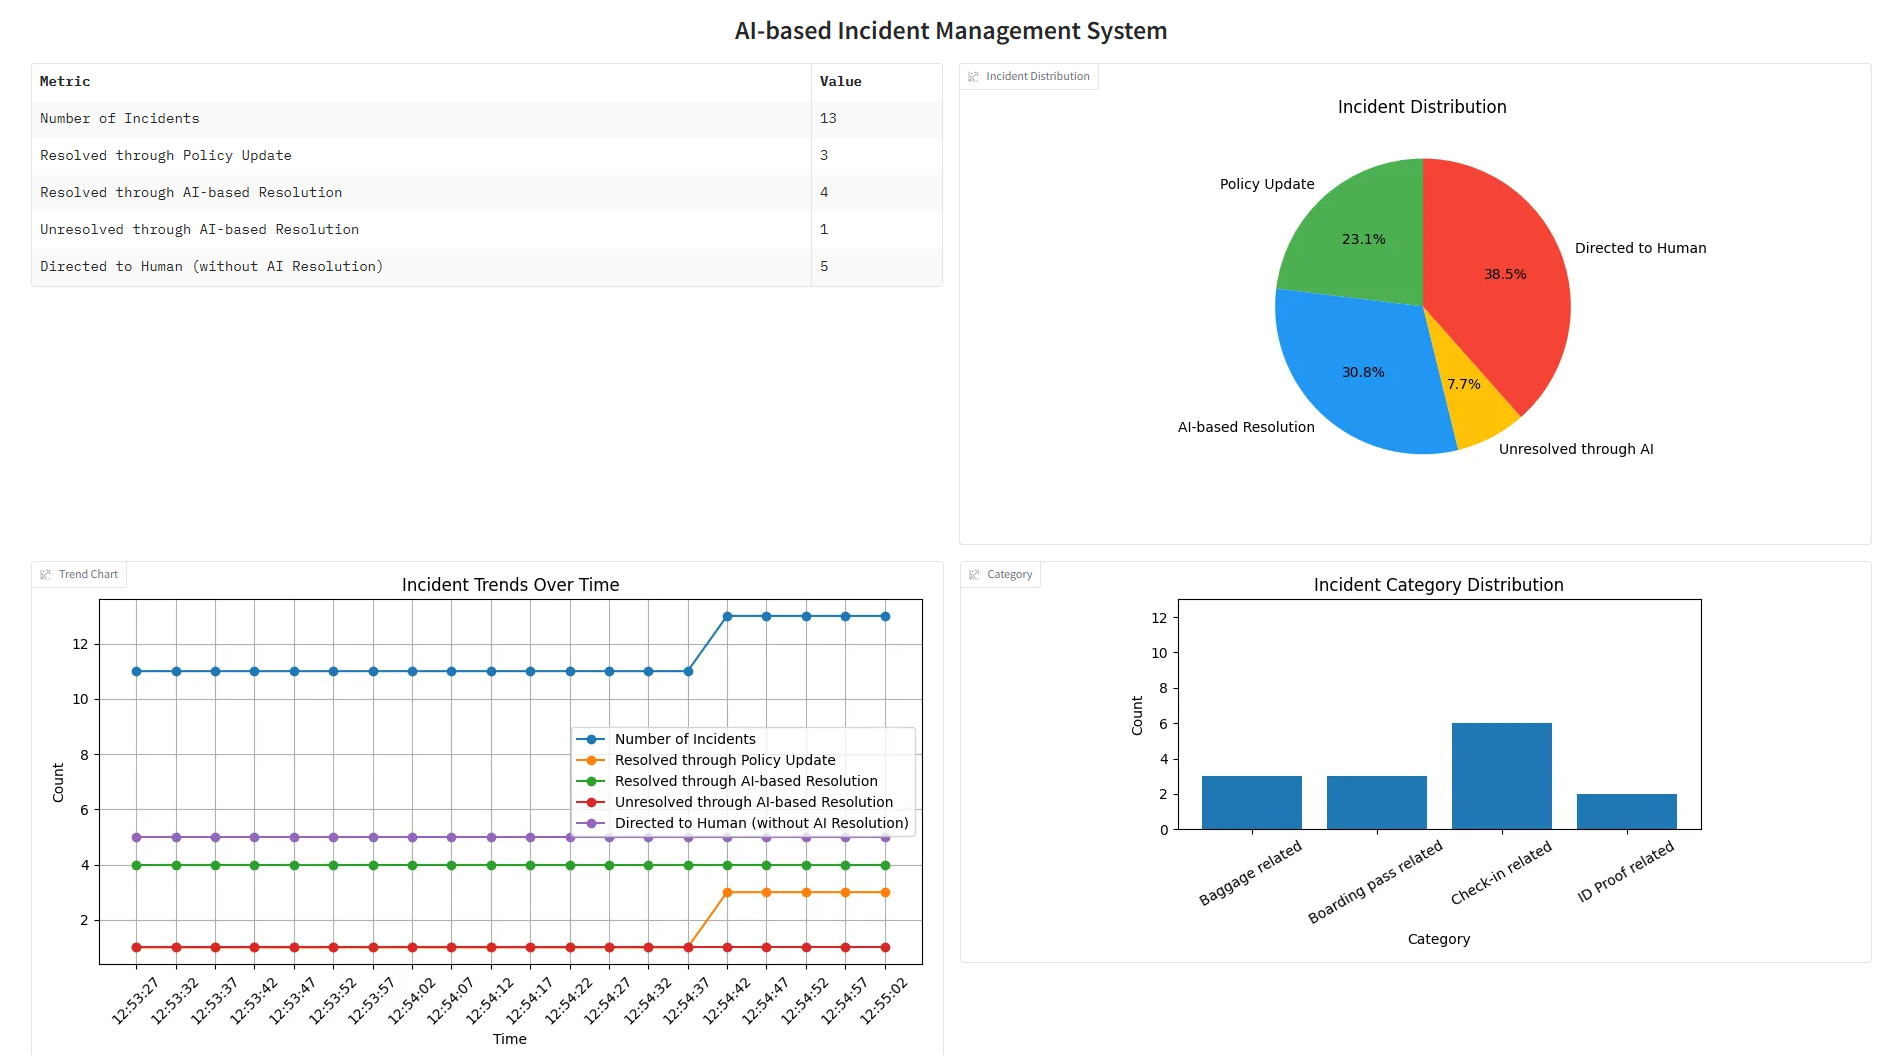

---

In [ ]:
import gradio as gr

In [ ]:
def get_summary_table():
    global data
    return pd.DataFrame(list(data.items()), columns=["Metric", "Value"])

In [ ]:
get_summary_table()

,Metric,Value
0,Number of Incidents,6
1,Resolved through Policy Update,1
2,Resolved through AI-based Resolution,2
3,Unresolved through AI-based Resolution,1
4,Directed to Human (without AI Resolution),2


In [ ]:
def get_incident_distribution_plot():
    global data

    pie_data = {
        "Policy Update": data["Resolved through Policy Update"],
        "AI-based Resolution": data["Resolved through AI-based Resolution"],
        "Unresolved through AI": data["Unresolved through AI-based Resolution"],
        "Directed to Human": data["Directed to Human (without AI Resolution)"]
    }

    pie_data_colors = {
        "Policy Update": "#4CAF50",
        "AI-based Resolution": "#2196F3",
        "Unresolved through AI": "#FFC107",
        "Directed to Human": "#F44336"
    }

    # Filter non-zero values
    filtered_data = {k: v for k, v in pie_data.items() if v > 0}

    if len(filtered_data) > 0:
        labels = list(filtered_data.keys())
        values = list(filtered_data.values())
        colors = [pie_data_colors[k] for k in filtered_data]

        fig, ax = plt.subplots()
        ax.pie(
            values,
            labels=labels,
            autopct="%1.1f%%",
            colors=colors,
            startangle=90
        )
        ax.set_title("Incident Distribution")

        return fig

    else:
        return None


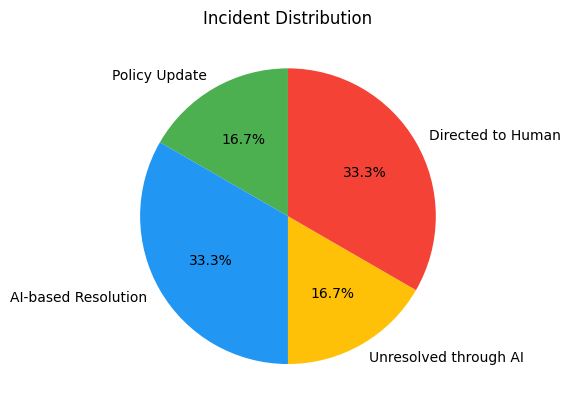

In [ ]:
get_incident_distribution_plot();

In [ ]:
history = []
prev_data = data  # store previous snapshot

# snapshot = {"Time": datetime.now().strftime("%H:%M:%S"), **data}
# history.append(snapshot)

def get_trend_plot():
    global history, prev_data, data

    # Check if data has changed
    # if list(prev_data.values()) != list(data.values()):
    snapshot = {"Time": datetime.now().strftime("%H:%M:%S"), **data}
    history.append(snapshot)
    prev_data = data   # update previous state

    # Keep last N points (optional)
    history = history[-20:]

    # Trend chart from history
    hist_df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(9, 5))
    metrics = [
        "Number of Incidents",
        "Resolved through Policy Update",
        "Resolved through AI-based Resolution",
        "Unresolved through AI-based Resolution",
        "Directed to Human (without AI Resolution)"
    ]

    for metric in metrics:
        ax.plot(hist_df["Time"], hist_df[metric], marker="o", label=metric)

    ax.set_title("Incident Trends Over Time")
    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig


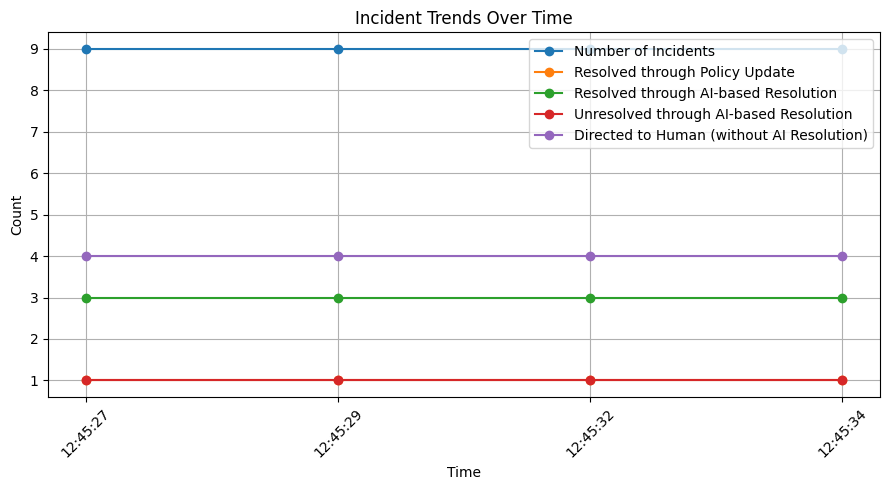

In [ ]:
get_trend_plot();

In [ ]:
def get_category_plot():
    global incident_category_data

    # Filter non-zero values (optional but recommended)
    filtered = {k: v for k, v in incident_category_data.items() if v > 0}

    if len(filtered) == 0:
        return None

    categories = list(filtered.keys())
    values = list(filtered.values())

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.bar(categories, values)

    ax.set_title("Incident Category Distribution")
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.set_ylim(0, data['Number of Incidents'])
    ax.set_yticks(range(0, data['Number of Incidents'] + 1, 2))

    plt.xticks(rotation=30)
    plt.tight_layout()

    return fig

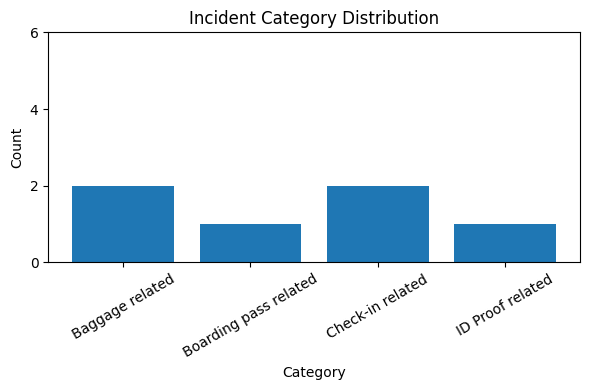

In [ ]:
get_category_plot();

In [ ]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


def fetch_updated_data():
    global history, prev_data, data

    df =  get_summary_table()

    incident_distribution_plot = get_incident_distribution_plot()

    trend_plot = get_trend_plot()

    category_plot = get_category_plot()

    return df, incident_distribution_plot, trend_plot, category_plot


In [ ]:
with gr.Blocks() as demo:
    # gr.Markdown("## Incident Dashboard")
    gr.Markdown("<h1 style='text-align: center;'>AI-based Incident Management System</h1>")

    with gr.Row():
        table = gr.DataFrame()
        incident_chart = gr.Plot(label="Incident Distribution")

    with gr.Row():
        trend_chart = gr.Plot(label="Trend Chart")
        category_chart = gr.Plot(label="Category")

    timer = gr.Timer(5)  # refresh every 5 seconds
    timer.tick(fetch_updated_data, outputs=[table, incident_chart, trend_chart, category_chart])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66efb6f4095be9acc6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Run the Incident Management Pipeline and provide sample incidents,
# then check the updates being reflected in the Dashboard.

run_incident_mgmt_pipeline()

====== Welcome to the Incident Management System! ======

Describe your incident: My boarding pass QR code is not scanning at the boarding gate.
Response:
1. Open the airline app and view your boarding pass; tap “Show QR code” to ensure it’s clear and not blurred.  
2. If the code looks fine, try re‑scanning it with the gate’s camera—hold the phone steady and keep the QR code centered.  
3. If it still fails, request a new boarding pass from the gate staff; they can print a fresh QR or provide a barcode.  
4. As a backup, ask the gate agent to manually verify your ID and ticket number so you can board.  
5. If the problem persists, contact the airline’s customer support via the app or phone for a replacement pass.

Does the resolution provided helps?: Yes it does
Response:
Thank you for your feedback! This incident is now closed.



In [ ]:
data, incident_category_data

({'Number of Incidents': 13,
  'Resolved through Policy Update': 3,
  'Resolved through AI-based Resolution': 4,
  'Unresolved through AI-based Resolution': 1,
  'Directed to Human (without AI Resolution)': 5},
 {'Baggage related': 3,
  'Boarding pass related': 3,
  'Check-in related': 6,
  'ID Proof related': 2,
  'Other': 0})